#โค้ด 1.1 ทำนายยอดขาย

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


คาดการณ์ยอดขายเดือนหน้า: 352.67 หน่วย


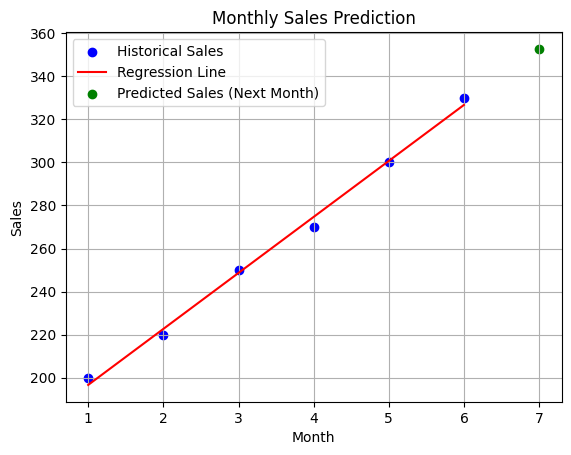

In [ ]:
#SAle prediction
import pandas as pd
from sklearn.linear_model import LinearRegression

# ข้อมูลตัวอย่าง: เดือน และยอดขาย
data = {
    "month": [1, 2, 3, 4, 5, 6],
    "sales": [200, 220, 250, 270, 300, 330]
}
df = pd.DataFrame(data)

# โมเดล Regression
X = df[["month"]]
y = df["sales"]
model = LinearRegression()
model.fit(X, y)

# ทำนายเดือนหน้า
next_month = [[7]]
prediction = model.predict(next_month)
print(f"คาดการณ์ยอดขายเดือนหน้า: {prediction[0]:.2f} หน่วย")
import matplotlib.pyplot as plt

# Plot historical data
plt.scatter(df["month"], df["sales"], color="blue", label="Historical Sales")
plt.plot(df["month"], model.predict(X), color="red", label="Regression Line")

# Plot prediction for next month
plt.scatter(next_month, prediction, color="green", label="Predicted Sales (Next Month)")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Prediction")
plt.legend()
plt.grid(True)
plt.show()

#โค้ด 1.2 การจัดการห่วงโซ่อุปทาน

In [ ]:
#ติดตั้งแพ็กเกจ
!pip install ortools

In [ ]:

from ortools.constraint_solver import pywrapcp, routing_enums_pb2
import numpy as np

# ตำแหน่งจำลอง (ร้าน + ลูกค้า 5 จุด)
locations = {
    'Shop': (13.7563, 100.5018),   # Bangkok
    'C1': (13.8, 100.55),
    'C2': (13.75, 100.6),
    'C3': (13.7, 100.52),
    'C4': (13.72, 100.48),
    'C5': (13.8, 100.48)
}

# แปลงพิกัดเป็น matrix ระยะทาง (Euclidean)
keys = list(locations.keys())
coords = np.array(list(locations.values()))
dist_matrix = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2) * 111  # km

# ตั้งค่า Routing Model
manager = pywrapcp.RoutingIndexManager(len(dist_matrix), 1, 0)
routing = pywrapcp.RoutingModel(manager)

def distance_callback(from_index, to_index):
    f = manager.IndexToNode(from_index)
    t = manager.IndexToNode(to_index)
    return int(dist_matrix[f][t] * 1000)  # meters

# Register the distance callback and set it as the arc cost evaluator
transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

# ใช้วิธีการค้นหาแบบ Greedy + Local Search
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
search_parameters.time_limit.seconds = 2

solution = routing.SolveWithParameters(search_parameters)

# แสดงผลลัพธ์
if solution:
    print("🚗 Optimal Route:")
    index = routing.Start(0)
    route = []
    while not routing.IsEnd(index):
        route.append(keys[manager.IndexToNode(index)])
        index = solution.Value(routing.NextVar(index))
    route.append(keys[manager.IndexToNode(index)])
    print(" ➜ ".join(route))
else:
    print("ไม่พบเส้นทางที่เหมาะสม")

🚗 Optimal Route:
Shop ➜ C4 ➜ C3 ➜ C2 ➜ C1 ➜ C5 ➜ Shop


#โค้ด 1.3 แนะนำสินค้าร้านเบเกอรี่

In [ ]:
# pip install pandas scikit-learn
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --------- 1) ข้อมูลสินค้า (ตัวอย่าง: ร้านเบเกอรี่) ----------
products = pd.DataFrame([
    # id, name, tags(ส่วนผสม/หมวด), price, rating, sales
    [1, "Strawberry Cheesecake", "cheesecake strawberry creamy sweet", 129, 4.7, 980],
    [2, "Blueberry Muffin",      "muffin blueberry fluffy sweet",      65,  4.5, 1220],
    [3, "Raspberry Tart",        "tart raspberry sour sweet butter",   95,  4.3, 640],
    [4, "Chocolate Brownie",     "brownie chocolate fudgy sweet",      75,  4.8, 2100],
    [5, "Lemon Pound Cake",      "cake lemon citrus sweet butter",     89,  4.2, 530],
    [6, "Matcha Roll Cake",      "roll cake matcha creamy",            99,  4.4, 720],
    [7, "Strawberry Shortcake",  "cake strawberry creamy light",       139, 4.6, 860],
    [8, "Blueberry Cheesecake",  "cheesecake blueberry creamy",        139, 4.7, 1050],
], columns=["id","name","tags","price","rating","sales"])

# --------- 2) Vectorize “tags” เพื่อทำ content-based ----------
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(products["tags"])  # (n_items x vocab)

# --------- 3) ฟังก์ชันแนะนำ ----------
def recommend_by_item(liked_item_name, k=5, w_pop=0.25, price_range=None):
    """
    liked_item_name: ชื่อสินค้าที่ผู้ใช้ชอบ เช่น 'Blueberry Muffin'
    k: จำนวนรายการแนะนำ
    w_pop: น้ำหนักความนิยม (0–1) ยิ่งมากยิ่งดันของขายดีขึ้น
    price_range: กรองราคา (min_price, max_price) หรือ None
    """
    # หา index ของสินค้าที่ชอบ
    try:
        idx = products.index[products["name"].str.lower() == liked_item_name.lower()][0]
    except IndexError:
        raise ValueError(f"ไม่พบสินค้า: {liked_item_name}")

    # similarity โดย cosine กับสินค้าที่ชอบ
    sim = cosine_similarity(X[idx], X).flatten()  # shape (n_items,)

    # สร้างคะแแนนความนิยมแบบ normalize จาก rating และ sales
    pop_rating = (products["rating"] - products["rating"].min()) / (products["rating"].max() - products["rating"].min())
    pop_sales  = (products["sales"]  - products["sales"].min())  / (products["sales"].max()  - products["sales"].min())
    popularity = 0.6 * pop_rating + 0.4 * pop_sales

    # hybrid score = (1 - w_pop)*similarity + w_pop*popularity
    score = (1 - w_pop)*sim + w_pop*popularity

    # ไม่แนะนำตัวมันเอง
    score[idx] = -1

    # กรองช่วงราคา (ถ้ามี)
    mask = pd.Series([True]*len(products))
    if price_range:
        lo, hi = price_range
        mask &= (products["price"] >= lo) & (products["price"] <= hi)

    # เลือก top-k
    top_idx = pd.Series(score).where(mask, -1).nlargest(k).index
    return products.loc[top_idx, ["id","name","price","rating","sales"]].assign(score=pd.Series(score).loc[top_idx].round(3))

# --------- 4) ทดลองใช้ ----------
print("ชอบ: Strawberry Cheesecake (เน้นคล้าย 80% + ความนิยม 20%) ")
print(recommend_by_item("Strawberry Cheesecake", k=5, w_pop=0.20, price_range=(60,120)))


#โค้ด 1.4 การจับคู่ระหว่างผู้โดยสารและรถยนต์

In [ ]:
from math import radians, sin, cos, asin, sqrt
import pandas as pd

# ---------------------------
# 1) Sample data
# ---------------------------
drivers = {
    "D1": (13.7563, 100.5018),  # Bangkok center
    "D2": (13.7450, 100.5340),
    "D3": (13.7300, 100.5100),
}

passengers = {
    # passenger_name: (pickup_lat, pickup_lon, drop_lat, drop_lon)
    "P1": (13.7600, 100.5100, 13.7700, 100.5200),
    "P2": (13.7400, 100.5200, 13.7350, 100.5000),
    "P3": (13.7200, 100.5050, 13.7000, 100.5000),
}

# ------------------------------------------------
# 2) Distance and ETA functions
# ------------------------------------------------
def haversine_km(lat1, lon1, lat2, lon2):
    """Compute great-circle distance between two coordinates (km)."""
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

def eta_minutes(distance_km, avg_speed_kmh=25.0, traffic_multiplier=1.0):
    """Rough ETA in minutes."""
    return (distance_km / avg_speed_kmh) * 60 * traffic_multiplier

# ------------------------------------------------
# 3) Compute driver–passenger costs
# ------------------------------------------------
ALPHA = 1.0  # distance to pickup weight
BETA  = 2.0  # trip ETA weight

def compute_cost(driver_loc, passenger_trip):
    d_lat, d_lon = driver_loc
    p_lat, p_lon, drop_lat, drop_lon = passenger_trip

    dist_pickup = haversine_km(d_lat, d_lon, p_lat, p_lon)
    trip_km = haversine_km(p_lat, p_lon, drop_lat, drop_lon)
    eta = eta_minutes(trip_km, avg_speed_kmh=25.0, traffic_multiplier=1.2)
    return ALPHA * dist_pickup + BETA * eta

# ------------------------------------------------
# 4) Greedy nearest-driver assignment
# ------------------------------------------------
unassigned_drivers = drivers.copy()
assignments = []

for pname, ptrip in passengers.items():
    if not unassigned_drivers:
        break  # no drivers left

    # compute cost for each available driver
    costs = {dname: compute_cost(dloc, ptrip) for dname, dloc in unassigned_drivers.items()}
    best_driver = min(costs, key=costs.get)
    best_cost = costs[best_driver]

    assignments.append({
        "passenger": pname,
        "driver": best_driver,
        "cost": round(best_cost, 2)
    })

    # remove driver from available list
    del unassigned_drivers[best_driver]

# ------------------------------------------------
# 5) Display results
# ------------------------------------------------
df = pd.DataFrame(assignments)
print("✅ Greedy matching results:\n", df)


✅ Greedy matching results:
   passenger driver   cost
0        P1     D1   9.91
1        P2     D3  14.40
2        P3     D2  17.37


#โค้ด 1.5 ระบบให้คำแนะนำในการออกกำลังกาย

In [ ]:
import pandas as pd
import numpy as np

# ---------------------------------------------------
# 1) สร้างข้อมูลจำลองและบันทึกเป็น smartwatch_data.csv
# อาจอ่านข้อมูลจากไฟล์ csv แทนก็ได้
# ---------------------------------------------------
np.random.seed(42)
data = {
    "heart_rate": np.random.randint(55, 110, 10),
    "sleep_hours": np.random.uniform(4.5, 9.0, 10),
    "steps": np.random.randint(2000, 12000, 10)
}
df = pd.DataFrame(data)
df.to_csv("smartwatch_data.csv", index=False)
print("✅ สร้างไฟล์ smartwatch_data.csv เรียบร้อย\n")
print(df.head())

# ---------------------------------------------------
# 2) อ่านข้อมูลและวิเคราะห์ด้วย rule-based AI
# ---------------------------------------------------
df = pd.read_csv("smartwatch_data.csv")

def recommend(row):
    hr = row["heart_rate"]
    sleep = row["sleep_hours"]
    steps = row["steps"]

    if hr > 90 and sleep < 6:
        return "แนะนำพักผ่อนเพิ่มเติม 😴"
    elif steps < 5000:
        return "ควรเดินเพิ่มอีกหน่อย 🚶‍♀️"
    elif hr < 65 and sleep >= 7:
        return "พร้อมออกกำลังกายแบบปานกลาง 🏃‍♂️"
    else:
        return "รักษาระดับการออกกำลังกายต่อเนื่อง 👍"

df["recommendation"] = df.apply(recommend, axis=1)

# ---------------------------------------------------
# 3) แสดงผลลัพธ์
# ---------------------------------------------------
print("\n📊 ผลการวิเคราะห์จากสมาร์ตวอทช์:")
print(df)


✅ สร้างไฟล์ smartwatch_data.csv เรียบร้อย

   heart_rate  sleep_hours  steps
0          93     4.761376   6555
1         106     8.397793   5385
2          83     7.205018   8396
3          69     7.686327  10666
4          97     4.592630  11274

📊 ผลการวิเคราะห์จากสมาร์ตวอทช์:
   heart_rate  sleep_hours  steps                       recommendation
0          93     4.761376   6555              แนะนำพักผ่อนเพิ่มเติม 😴
1         106     8.397793   5385  รักษาระดับการออกกำลังกายต่อเนื่อง 👍
2          83     7.205018   8396  รักษาระดับการออกกำลังกายต่อเนื่อง 👍
3          69     7.686327  10666  รักษาระดับการออกกำลังกายต่อเนื่อง 👍
4          97     4.592630  11274              แนะนำพักผ่อนเพิ่มเติม 😴
5          62     8.864594   4558            ควรเดินเพิ่มอีกหน่อย 🚶‍♀️
6          75     8.245992   9849  รักษาระดับการออกกำลังกายต่อเนื่อง 👍
7          93     5.455526   4047              แนะนำพักผ่อนเพิ่มเติม 😴
8          73     5.318212   4747            ควรเดินเพิ่มอีกหน่อย 🚶‍♀️
9         

#โค้ด	1.6 ระบบแนะนำหนังหรือเพลง
แนะนำหนังเพลง
ใช้การวิเคราะห์ 3 วิธี (Popularity, Content-Based, Item-Based CF) พร้อมทำ Hybrid หรือรวมคะแนน
* Popularity: ของที่คนดู/ฟังเยอะสุด → baseline ง่ายและแรง
* Content-Based: เทียบความคล้ายของ “เนื้อหา/แท็ก/ศิลปิน/แนวเพลง/แนวหนัง” กับรสนิยมผู้ใช้
* Item-Based Collaborative Filtering: ถ้าคุณชอบ A และคนที่ชอบ A มักชอบ B → ก็แนะนำ B ให้คุณ






In [ ]:
# -*- coding: utf-8 -*-
"""
Recommender for Movies & Music (Netflix/YouTube/Spotify style, simplified)
- Popularity
- Content-Based (TF-IDF + Cosine)
- Item-Based Collaborative Filtering (Cosine on item vectors)
- Hybrid (weighted sum)
"""

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# 1) เตรียม "แคตตาล็อก" สินค้า (หนัง/เพลง)
#    สามารถแทนที่ด้วยการอ่านจาก CSV ได้:
#    items = pd.read_csv("items.csv")
#    events = pd.read_csv("events.csv")
# ------------------------------------------------------------
items = pd.DataFrame([
    # item_id, type,             title,                      genres_tags,                      artist_or_director, year
    (1,       "movie",          "Planet Escape",            "scifi adventure space epic",     "N. Corelli",       2023),
    (2,       "movie",          "Love in Bangkok",          "romance drama asia thailand",    "A. Siriporn",      2021),
    (3,       "movie",          "The Debugger",             "tech thriller hacker ai",        "K. Nakamura",      2022),
    (4,       "music",          "Midnight Lo-Fi",           "lofi chill beats study",         "DJ Nebula",        2020),
    (5,       "music",          "Bangkok Groove",           "funk thai pop dance",            "Groove Siam",      2024),
    (6,       "music",          "Code & Coffee",            "indie acoustic focus chill",     "The Coders",       2019),
    (7,       "movie",          "Green Trails",             "adventure nature travel",        "M. Alvarez",       2020),
    (8,       "music",          "Neural Nights",            "edm electronic ai synth",        "ByteBeat",         2022),
    (9,       "movie",          "Data Hearts",              "romance comedy tech startup",    "L. Chen",          2024),
    (10,      "music",          "Thaitone Sunrise",         "thai traditional instrumental",  "Ruen Thai",        2021),
], columns=["item_id","type","title","genres_tags","artist_or_director","year"])

# ------------------------------------------------------------
# 2) สร้าง "พฤติกรรมผู้ใช้" (implicit feedback)
#    event_type: play, watch, like, skip, rating(1..5)
#    เราจะแปลงเป็น "score" อย่างง่าย (ปรับน้ำหนักได้)
# ------------------------------------------------------------
events = pd.DataFrame([
    # user, item, event, value(optional)
    (101, 1, "watch",  1),
    (101, 3, "watch",  1),
    (101, 4, "play",   3),
    (101, 6, "play",   5),
    (101, 8, "play",   2),
    (101, 6, "like",   1),

    (102, 2, "watch",  1),
    (102, 5, "play",   4),
    (102, 5, "like",   1),
    (102, 9, "watch",  1),

    (103, 4, "play",   6),
    (103, 8, "play",   5),
    (103, 1, "watch",  1),
    (103, 7, "watch",  1),

    (104, 10,"play",   3),
    (104, 2, "watch",  1),
    (104, 9, "watch",  1),
], columns=["user_id","item_id","event_type","value"])

# รวม rule แปลง event -> score
EVENT_WEIGHT = {
    "play":   1.0,  # ใช้จำนวนครั้ง play เป็นฐาน
    "watch":  2.0,  # หนัง 1 ครั้งมีน้ำหนักมากกว่าการกด play เพลงครั้งเดียว
    "like":   3.0,  # กดถูกใจ = สัญญาณเจาะจงสูง
    # ตัวอย่าง rating 1..5 ถ้ามี: score = value * 3.0 เป็นต้น
}

def to_score(row):
    if row["event_type"] == "rating":
        return float(row.get("value", 0)) * 3.0
    base = EVENT_WEIGHT.get(row["event_type"], 0.5)
    return base * float(row.get("value", 1.0))

events["score"] = events.apply(to_score, axis=1)

# ------------------------------------------------------------
# 3) Popularity Model: รวมคะแนนทุกคน → จัดอันดับ
# ------------------------------------------------------------
popularity = (
    events.groupby("item_id")["score"]
    .sum()
    .reset_index()
    .rename(columns={"score":"pop_score"})
)

# ------------------------------------------------------------
# 4) Content-Based: TF-IDF ของ (genres_tags + artist_or_director)
#    แล้วสร้าง "user profile" จากรายการที่ผู้ใช้มีคะแนนสูง
# ------------------------------------------------------------
items["content"] = items["genres_tags"].fillna("") + " " + items["artist_or_director"].fillna("")
tfidf = TfidfVectorizer(min_df=1, ngram_range=(1,2))
item_tfidf = tfidf.fit_transform(items["content"])  # shape: (n_items, n_terms)

# เตรียม user vectors จาก interactions (เลือก top items ของแต่ละ user)
def build_user_profile(user_id, top_k=5):
    u = events[events["user_id"] == user_id]
    if u.empty:
        return None
    # เลือกไอเท็มที่คะแนนสูงสุดของ user
    top = (
        u.sort_values("score", ascending=False)
         .head(top_k)["item_id"].values
    )
    # index ของ item ในตาราง items
    idx = items[items["item_id"].isin(top)].index.values
    if len(idx) == 0:
        return None
    # โปรไฟล์ = average TF-IDF ของไอเท็มที่ผู้ใช้ชอบ
    profile = item_tfidf[idx].mean(axis=0)
    return profile

def content_based_scores_for_user(user_id):
    profile = build_user_profile(user_id)
    if profile is None:
        # ไม่มีประวัติ → ให้ศูนย์
        return pd.Series(0.0, index=items["item_id"])
    # cosine(user_profile, item_vector)
    sims = cosine_similarity(np.asarray(profile), item_tfidf).flatten()  # length = n_items
    return pd.Series(sims, index=items["item_id"])

# ------------------------------------------------------------
# 5) Item-Based Collaborative Filtering:
#    - สร้าง user-item matrix (implicit score)
#    - คำนวณ item-item cosine similarity
#    - ให้คะแนนไอเท็มใหม่จาก weighted sum ของสิ่งที่ user เคยมี
# ------------------------------------------------------------
# user-item matrix
ui = events.pivot_table(index="user_id", columns="item_id", values="score", aggfunc="sum", fill_value=0.0)
item_ids = ui.columns.values

# item-item cosine (บนคอลัมน์)
if ui.shape[0] >= 1:
    item_vecs = ui.T.values  # shape: (n_items, n_users)
    item_sims = cosine_similarity(item_vecs)  # square matrix (n_items, n_items)
    item_sim_df = pd.DataFrame(item_sims, index=item_ids, columns=item_ids)
else:
    # fallback
    item_sim_df = pd.DataFrame(0.0, index=items["item_id"], columns=items["item_id"])

def item_based_scores_for_user(user_id, top_k_neighbors=5):
    if user_id not in ui.index:
        return pd.Series(0.0, index=items["item_id"])
    user_row = ui.loc[user_id]  # scores of items the user interacted
    owned = user_row[user_row > 0.0]
    if owned.empty:
        return pd.Series(0.0, index=items["item_id"])

    scores = pd.Series(0.0, index=item_sim_df.columns)
    for i_item, i_score in owned.items():
        # หาเพื่อนบ้านที่คล้ายกับ i_item มากสุด
        neighbors = (
            item_sim_df.loc[i_item]
                       .drop(index=i_item)  # ไม่เทียบกับตัวเอง
                       .sort_values(ascending=False)
                       .head(top_k_neighbors)
        )
        # ถ่วงน้ำหนักด้วยคะแนนที่ user เคยให้ i_item
        scores = scores.add(neighbors * i_score, fill_value=0.0)

    return scores

# ------------------------------------------------------------
# 6) รวมคะแนน (Hybrid)
#    weights: w_pop, w_content, w_itemcf
#    สามารถกรองเฉพาะ movie หรือ music ด้วย type_filter ได้
# ------------------------------------------------------------
def recommend_for_user(user_id, k=10, weights=(0.2, 0.4, 0.4), type_filter=None, exclude_consumed=True):
    w_pop, w_content, w_item = weights

    # เตรียมคะแนนแต่ละโมเดล
    s_pop = popularity.set_index("item_id")["pop_score"].reindex(items["item_id"]).fillna(0.0)
    s_pop = s_pop / (s_pop.max() + 1e-9)  # normalize 0..1

    s_content = content_based_scores_for_user(user_id)
    if s_content.max() > 0:
        s_content = s_content / s_content.max()

    s_itemcf = item_based_scores_for_user(user_id)
    if s_itemcf.max() > 0:
        s_itemcf = s_itemcf / s_itemcf.max()

    hybrid = w_pop * s_pop + w_content * s_content + w_item * s_itemcf
    rec_df = items.copy()
    rec_df["score_pop"] = s_pop.values
    rec_df["score_content"] = rec_df["item_id"].map(s_content.to_dict()).fillna(0.0)
    rec_df["score_itemcf"] = rec_df["item_id"].map(s_itemcf.to_dict()).fillna(0.0)
    rec_df["score_hybrid"] = rec_df[["score_pop","score_content","score_itemcf"]].dot(np.array([w_pop,w_content,w_item]))

    # กรองประเภท
    if type_filter in {"movie","music"}:
        rec_df = rec_df[rec_df["type"] == type_filter]

    # ตัดของที่ user เคยดู/ฟังแล้ว (ถ้าต้องการ)
    if exclude_consumed and user_id in events["user_id"].values:
        consumed = set(events.query("user_id == @user_id")["item_id"].unique().tolist())
        rec_df = rec_df[~rec_df["item_id"].isin(consumed)]

    rec_df = rec_df.sort_values("score_hybrid", ascending=False)
    return rec_df.head(k)[["item_id","type","title","year","score_pop","score_content","score_itemcf","score_hybrid"]]

# ------------------------------------------------------------
# 7) ตัวอย่างการใช้งาน
# ------------------------------------------------------------
if __name__ == "__main__":
    target_user = 101

    print("\n=== Hybrid (หนัง + เพลง) ===")
    print(recommend_for_user(target_user, k=5, weights=(0.2, 0.5, 0.3)))

    print("\n=== เฉพาะหนัง (movie) ===")
    print(recommend_for_user(target_user, k=5, weights=(0.2, 0.5, 0.3), type_filter="movie"))

    print("\n=== เฉพาะเพลง (music) ===")
    print(recommend_for_user(target_user, k=5, weights=(0.2, 0.5, 0.3), type_filter="music"))

    # กรณีผู้ใช้ใหม่ (cold-start): ไม่มี events → ใช้ popularity + content จาก profile ที่ว่าง (จะกลายเป็น 0)
    new_user = 999
    print("\n=== ผู้ใช้ใหม่ (cold-start) ใช้ Popularity เป็นหลัก ===")
    print(recommend_for_user(new_user, k=5, weights=(1.0, 0.0, 0.0)))


=== Hybrid (หนัง + เพลง) ===
   item_id   type             title  year  score_pop  score_content  \
6        7  movie      Green Trails  2020   0.222222       0.088412   
4        5  music    Bangkok Groove  2024   0.777778       0.000000   
8        9  movie       Data Hearts  2024   0.444444       0.080166   
1        2  movie   Love in Bangkok  2021   0.444444       0.000000   
9       10  music  Thaitone Sunrise  2021   0.333333       0.000000   

   score_itemcf  score_hybrid  
6      0.506528      0.240609  
4      0.000000      0.155556  
8      0.000000      0.128972  
1      0.000000      0.088889  
9      0.000000      0.066667  

=== เฉพาะหนัง (movie) ===
   item_id   type            title  year  score_pop  score_content  \
6        7  movie     Green Trails  2020   0.222222       0.088412   
8        9  movie      Data Hearts  2024   0.444444       0.080166   
1        2  movie  Love in Bangkok  2021   0.444444       0.000000   

   score_itemcf  score_hybrid  
6      0.50

#ระบบแนะนำการออกกำลังกายด้วย Machine Learning

In [ ]:
# pip install scikit-learn pandas numpy
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# -----------------------------
# 1) สร้างข้อมูลจำลองจาก Smartwatch
# -----------------------------
np.random.seed(42)

n = 200
data = pd.DataFrame({
    "heart_rate": np.random.randint(55, 110, n),       # อัตราการเต้นหัวใจ (bpm)
    "sleep_hours": np.random.uniform(4, 9, n).round(1), # เวลานอน (ชั่วโมง)
    "steps": np.random.randint(2000, 15000, n),         # จำนวนก้าว
})

# -----------------------------
# 2) สร้าง Label (ประเภทคำแนะนำ)
# -----------------------------
def label_rule(row):
    hr, sl, st = row["heart_rate"], row["sleep_hours"], row["steps"]

    if sl < 5 and hr > 90:
        return "พักผ่อน"
    elif st < 5000 and sl >= 6:
        return "ออกกำลังกายเบา"
    elif 5000 <= st < 10000:
        return "ออกกำลังกายปานกลาง"
    elif st >= 10000 and hr < 85:
        return "ออกกำลังกายหนัก"
    else:
        return "ยืดกล้ามเนื้อ"

data["recommend"] = data.apply(label_rule, axis=1)

print("ตัวอย่างข้อมูล Smartwatch:")
print(data.head())

# -----------------------------
# 3) แบ่งชุดข้อมูล train / test
# -----------------------------
X = data[["heart_rate", "sleep_hours", "steps"]]
y = data["recommend"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# -----------------------------
# 4) สร้างและฝึกโมเดล ML (Random Forest)
# -----------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# 5) ทดสอบโมเดล
# -----------------------------
y_pred = model.predict(X_test)
print("\n📊 ผลการประเมินโมเดล:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 6) ทำนายคำแนะนำจากข้อมูลใหม่ (จำลองจาก Smartwatch)
# -----------------------------
new_data = pd.DataFrame({
    "heart_rate": [92, 70, 82, 60],
    "sleep_hours": [4.5, 7.2, 6.5, 8.0],
    "steps": [3500, 6200, 10500, 4000],
})

predictions = model.predict(new_data)
new_data["AI_Recommendation"] = predictions

print("\n🧠 คำแนะนำจาก AI (ข้อมูลใหม่):")
print(new_data)


#โค้ด 1.7 ระบบแนะนำในบ้านอัจฉริยะ
“การจดจำพฤติกรรม (Behavior Learning) จากข้อมูลเซนเซอร์ในบ้านอัจฉริยะ”
แล้วแนะนำให้ IoT ทำงานอัตโนมัติ เช่น เปิดไฟครัว 6 โมงเช้า / ตั้งแอร์ 25°C ตอนกลางคืน / เปิด Spotify ทุกวันศุกร์
โค้ดนี้ทำ 4 อย่างหลัก ๆ
* จำลองข้อมูลเซนเซอร์ (motion, ไฟ, แอร์, spotify, เวลา, วันในสัปดาห์)
* สร้าง label ของ “พฤติกรรม” ตามนิสัยสมมุติของผู้อยู่อาศัย
* เทรนโมเดล Multi-Output Random Forest เพื่อเรียนรู้ pattern
* สร้างฟังก์ชัน predict_behavior() เพื่อให้ AI แนะนำว่าจะสั่ง IoT อะไรตอนนี้ดี

In [ ]:
"""
ตัวอย่าง Behavior Learning สำหรับบ้านอัจฉริยะ
- ใช้ข้อมูลจำลองจากเซนเซอร์ (motion, temp, ฯลฯ)
- เรียนรู้พฤติกรรมเช่น:
    * เปิดไฟห้องครัวตอน 6 โมงเช้า
    * ตั้งแอร์ 25°C ตอนกลางคืน
    * เปิด Spotify ทุกวันศุกร์ตอนเย็น
- ใช้ RandomForest + MultiOutputClassifier
"""

import numpy as np
import pandas as pd
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report


# ---------------------------------------------------
# 1) สร้างข้อมูลจำลองจาก Sensor
# ---------------------------------------------------

def generate_smart_home_data(days: int = 60, interval_minutes: int = 30, random_state: int = 42):
    """
    จำลอง log ข้อมูลเซนเซอร์ในบ้านอัจฉริยะ
    - มี timestamp, วันในสัปดาห์, ช่วงเวลา, motion ฯลฯ
    - และสร้าง label ของ action ที่ผู้อยู่อาศัยทำเป็นนิสัย
    """
    rng = np.random.default_rng(random_state)

    start_time = datetime(2025, 1, 1, 0, 0, 0)
    records = []

    total_steps = int((24 * 60 / interval_minutes) * days)

    for step in range(total_steps):
        ts = start_time + timedelta(minutes=interval_minutes * step)
        hour = ts.hour
        minute = ts.minute
        weekday = ts.weekday()  # Monday=0 ... Sunday=6

        # ---------- Features (จาก sensor & context) ----------
        # motion sensor (ครัว, ห้องนั่งเล่น, ห้องนอน)
        motion_kitchen = rng.binomial(1, 0.1)   # โดยทั่วไปโอกาสน้อย
        motion_living = rng.binomial(1, 0.15)
        motion_bedroom = rng.binomial(1, 0.2)

        # อุณหภูมิภายนอก (สมมุติง่าย ๆ)
        # กลางวันร้อน กลางคืนเย็น
        base_temp = 30 - 8 * np.cos(2 * np.pi * (hour - 14) / 24)
        noise = rng.normal(0, 1.5)
        outside_temp = base_temp + noise

        # สถานะปัจจุบันของอุปกรณ์ (ก่อน action)
        light_kitchen_on = rng.binomial(1, 0.2)
        ac_on = rng.binomial(1, 0.5)
        ac_setpoint = rng.integers(23, 29)  # 23–28 องศา
        spotify_on = rng.binomial(1, 0.05)

        # ---------------------------------------------------
        # 2) กำหนดนิสัยของผู้อยู่อาศัย (Ground Truth Behavior)
        # ---------------------------------------------------
        # เรากำหนดเป็น "กฎพื้นฐาน" แล้วเพิ่ม noise
        # เพื่อใช้เป็น label ให้โมเดลเรียนรู้

        # a) เปิดไฟห้องครัวตอน 6:00–6:30 ทุกวัน (habit)
        habit_kitchen_light = (hour == 6) and (minute < 30)

        # b) ตั้งแอร์ 25°C ตอนกลางคืน 22:00–23:30
        habit_night_ac_25 = (hour >= 22 or hour <= 1)  # คืนค่า True ตั้งแต่ 22.00 ถึงตี 1
        # (simplify: ถ้าอยากแม่นเรื่อง time-range ใช้ช่วงเวลา 22–23 แล้วตี 0–1 เป็นคืนต่อ)

        # c) เปิด Spotify ทุกคืนวันศุกร์ 19:00–23:00
        habit_spotify_friday = (weekday == 4) and (19 <= hour <= 23)

        # แปลงเป็น Action / label ที่เราต้องการให้โมเดลเรียนรู้
        action_turn_on_kitchen_light = int(habit_kitchen_light or (motion_kitchen and hour == 6))
        action_set_ac_25 = int(habit_night_ac_25 and ac_on)
        action_turn_on_spotify = int(habit_spotify_friday)

        # เพิ่ม noise เล็กน้อย (บางวันลืมหรือไม่อยู่บ้าน)
        if rng.random() < 0.05:  # 5% ลืมเปิดไฟตามปกติ
            action_turn_on_kitchen_light = 0
        if rng.random() < 0.07:  # 7% ไม่ตั้งแอร์ 25 ตามปกติ
            action_set_ac_25 = 0
        if rng.random() < 0.1:   # 10% ไม่เปิด Spotify ศุกร์เย็น
            action_turn_on_spotify = 0

        records.append({
            "timestamp": ts,
            "weekday": weekday,
            "hour": hour,
            "minute": minute,
            "motion_kitchen": motion_kitchen,
            "motion_living": motion_living,
            "motion_bedroom": motion_bedroom,
            "outside_temp": outside_temp,
            "light_kitchen_on": light_kitchen_on,
            "ac_on": ac_on,
            "ac_setpoint": ac_setpoint,
            "spotify_on": spotify_on,
            # labels / actions ที่ต้องการให้โมเดลเรียนรู้
            "y_kitchen_light": action_turn_on_kitchen_light,
            "y_ac_25": action_set_ac_25,
            "y_spotify": action_turn_on_spotify,
        })

    df = pd.DataFrame(records)
    return df


# สร้างข้อมูลจำลอง
df = generate_smart_home_data(days=60, interval_minutes=30)

print("ตัวอย่างข้อมูลต้นทาง (head):")
print(df.head())


# ---------------------------------------------------
# 3) เตรียมข้อมูล X (features) และ y (labels)
# ---------------------------------------------------
feature_cols = [
    "weekday",
    "hour",
    "minute",
    "motion_kitchen",
    "motion_living",
    "motion_bedroom",
    "outside_temp",
    "light_kitchen_on",
    "ac_on",
    "ac_setpoint",
    "spotify_on",
]

label_cols = [
    "y_kitchen_light",   # 1 = ควรเปิดไฟครัว
    "y_ac_25",           # 1 = ควรตั้งแอร์ 25°C
    "y_spotify",         # 1 = ควรเปิด Spotify
]

X = df[feature_cols]
y = df[label_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y["y_kitchen_light"]
)

print("\nขนาดชุดเทรน:", X_train.shape, "ขนาดชุดทดสอบ:", X_test.shape)


# ---------------------------------------------------
# 4) สร้างโมเดล Multi-Output สำหรับหลาย ๆ action พร้อมกัน
# ---------------------------------------------------
base_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model = MultiOutputClassifier(base_model)
model.fit(X_train, y_train)

# ---------------------------------------------------
# 5) ประเมินโมเดล
# ---------------------------------------------------
y_pred = model.predict(X_test)

print("\n=== รายงานผลการจำแนกแต่ละพฤติกรรม ===")
for i, col in enumerate(label_cols):
    print(f"\n>>> พฤติกรรม: {col}")
    print(classification_report(y_test[col], y_pred[:, i]))


# ---------------------------------------------------
# 6) ฟังก์ชันใช้โมเดลทำนาย “ควรสั่ง IoT อะไรตอนนี้”
# ---------------------------------------------------

def predict_behavior(
    model,
    now: datetime,
    motion_kitchen: int,
    motion_living: int,
    motion_bedroom: int,
    outside_temp: float,
    light_kitchen_on: int,
    ac_on: int,
    ac_setpoint: int,
    spotify_on: int,
):
    """
    ป้อนสถานะปัจจุบันของบ้าน + เวลา
    แล้วใช้โมเดลทำนายว่าควร:
        - เปิดไฟครัวไหม
        - ตั้งแอร์ 25°C ไหม
        - เปิด Spotify ไหม
    """
    weekday = now.weekday()
    hour = now.hour
    minute = now.minute

    row = pd.DataFrame([{
        "weekday": weekday,
        "hour": hour,
        "minute": minute,
        "motion_kitchen": motion_kitchen,
        "motion_living": motion_living,
        "motion_bedroom": motion_bedroom,
        "outside_temp": outside_temp,
        "light_kitchen_on": light_kitchen_on,
        "ac_on": ac_on,
        "ac_setpoint": ac_setpoint,
        "spotify_on": spotify_on,
    }])

    pred = model.predict(row)[0]

    result = {
        "turn_on_kitchen_light": bool(pred[0]),
        "set_ac_25": bool(pred[1]),
        "turn_on_spotify": bool(pred[2]),
    }
    return result


# ---------------------------------------------------
# 7) ทดลองใช้โมเดลกับสถานการณ์ตัวอย่าง
# ---------------------------------------------------
# ตัวอย่าง: วันศุกร์ 19:10 น. คนอยู่ในห้องนั่งเล่น อุณหภูมิร้อน แอร์เปิดอยู่
example_time = datetime(2025, 2, 7, 19, 10)  # ศุกร์
example_pred = predict_behavior(
    model=model,
    now=example_time,
    motion_kitchen=0,
    motion_living=1,
    motion_bedroom=0,
    outside_temp=32.0,
    light_kitchen_on=0,
    ac_on=1,
    ac_setpoint=26,
    spotify_on=0,
)

print("\n=== ตัวอย่างการทำนายพฤติกรรมจาก context ปัจจุบัน ===")
print("เวลา:", example_time)
print("คำแนะนำของ AI:", example_pred)

# ---------------------------------------------------
# 8) ตัวอย่าง pseudo-code ต่อกับ IoT จริง
# ---------------------------------------------------
def send_command_to_iot(actions: dict):
    """
    ฟังก์ชันตัวอย่าง (ยังไม่ต่อกับอุปกรณ์จริง)
    ในระบบจริง คุณจะเรียก API ของ Home Assistant / MQTT / HTTP ฯลฯ
    """
    if actions["turn_on_kitchen_light"]:
        print("[IoT] สั่งเปิดไฟห้องครัว")
    if actions["set_ac_25"]:
        print("[IoT] สั่งตั้งแอร์ = 25°C")
    if actions["turn_on_spotify"]:
        print("[IoT] สั่งเปิด Spotify playlist วันศุกร์เย็น")


print("\n=== ส่งคำสั่งไปยัง IoT (จำลอง) ===")
send_command_to_iot(example_pred)


ตัวอย่างข้อมูลต้นทาง (head):
            timestamp  weekday  hour  minute  motion_kitchen  motion_living  \
0 2025-01-01 00:00:00        2     0       0               0              0   
1 2025-01-01 00:30:00        2     0      30               1              0   
2 2025-01-01 01:00:00        2     1       0               0              1   
3 2025-01-01 01:30:00        2     1      30               0              0   
4 2025-01-01 02:00:00        2     2       0               0              0   

   motion_bedroom  outside_temp  light_kitchen_on  ac_on  ac_setpoint  \
0               1     38.339050                 0      1           27   
1               1     37.629467                 0      1           27   
2               1     37.084915                 0      0           25   
3               0     39.420865                 0      0           23   
4               1     38.348242                 0      0           24   

   spotify_on  y_kitchen_light  y_ac_25  y_spotify  
0   